In [19]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
sriharshaeedala_airline_delay_path = kagglehub.dataset_download('sriharshaeedala/airline-delay')

print('Data source import complete.')


Using Colab cache for faster access to the 'airline-delay' dataset.
Data source import complete.


In [20]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
sns.set_style("whitegrid")

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/airline-delay/Airline_Delay_Cause.csv


In [21]:
import os
df=pd.read_csv(os.path.join(sriharshaeedala_airline_delay_path, "Airline_Delay_Cause.csv"))
df.head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


In [22]:
df = df.drop_duplicates()

In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 171666 entries, 0 to 171665
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 171666 non-null  int64  
 1   month                171666 non-null  int64  
 2   carrier              171666 non-null  object 
 3   carrier_name         171666 non-null  object 
 4   airport              171666 non-null  object 
 5   airport_name         171666 non-null  object 
 6   arr_flights          171426 non-null  float64
 7   arr_del15            171223 non-null  float64
 8   carrier_ct           171426 non-null  float64
 9   weather_ct           171426 non-null  float64
 10  nas_ct               171426 non-null  float64
 11  security_ct          171426 non-null  float64
 12  late_aircraft_ct     171426 non-null  float64
 13  arr_cancelled        171426 non-null  float64
 14  arr_diverted         171426 non-null  float64
 15  arr_delay        

In [24]:
df.isnull().sum()

,0
year,0
month,0
carrier,0
carrier_name,0
airport,0
airport_name,0
arr_flights,240
arr_del15,443
carrier_ct,240
weather_ct,240


In [25]:
empty_cols = [
    'arr_flights','arr_del15','carrier_ct','weather_ct','nas_ct','security_ct',
    'late_aircraft_ct','arr_cancelled','arr_diverted','arr_delay',
    'carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay'
]

# fill missing with the mean
for col in empty_cols:
    df[col] = df[col].fillna(df[col].mean())


In [26]:
df['date']=pd.to_datetime(df[['year', 'month']].assign(DAY=1))

In [27]:
print(df.head(5))

   year  month carrier       carrier_name airport  \
0  2023      8      9E  Endeavor Air Inc.     ABE   
1  2023      8      9E  Endeavor Air Inc.     ABY   
2  2023      8      9E  Endeavor Air Inc.     AEX   
3  2023      8      9E  Endeavor Air Inc.     AGS   
4  2023      8      9E  Endeavor Air Inc.     ALB   

                                        airport_name  arr_flights  arr_del15  \
0  Allentown/Bethlehem/Easton, PA: Lehigh Valley ...         89.0       13.0   
1             Albany, GA: Southwest Georgia Regional         62.0       10.0   
2           Alexandria, LA: Alexandria International         62.0       10.0   
3        Augusta, GA: Augusta Regional at Bush Field         66.0       12.0   
4                   Albany, NY: Albany International         92.0       22.0   

   carrier_ct  weather_ct  ...  late_aircraft_ct  arr_cancelled  arr_diverted  \
0        2.25        1.60  ...              5.99            2.0           1.0   
1        1.97        0.04  ...        

In [28]:
df['delay_rate'] = df['arr_del15'] / df['arr_flights'].replace(0, 1)
df.head()


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,date,delay_rate
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0,2023-08-01,0.146067
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0,2023-08-01,0.161290
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0,2023-08-01,0.161290
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0,2023-08-01,0.181818
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0,2023-08-01,0.239130


In [29]:
path = 'output.csv'
df.to_csv(path, index=False)
print(f'File saved successfully to: {os.path.abspath(path)}')

File saved successfully to: /content/output.csv


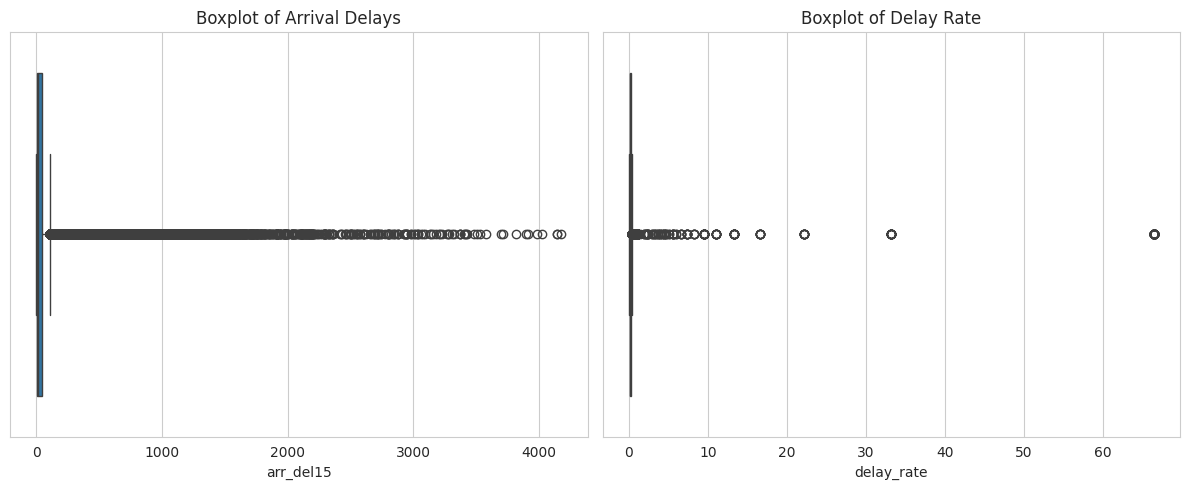

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

sns.boxplot(x=df['arr_del15'], ax=axes[0])
axes[0].set_title("Boxplot of Arrival Delays")

sns.boxplot(x=df['delay_rate'], ax=axes[1])
axes[1].set_title("Boxplot of Delay Rate")

plt.tight_layout()
plt.show()

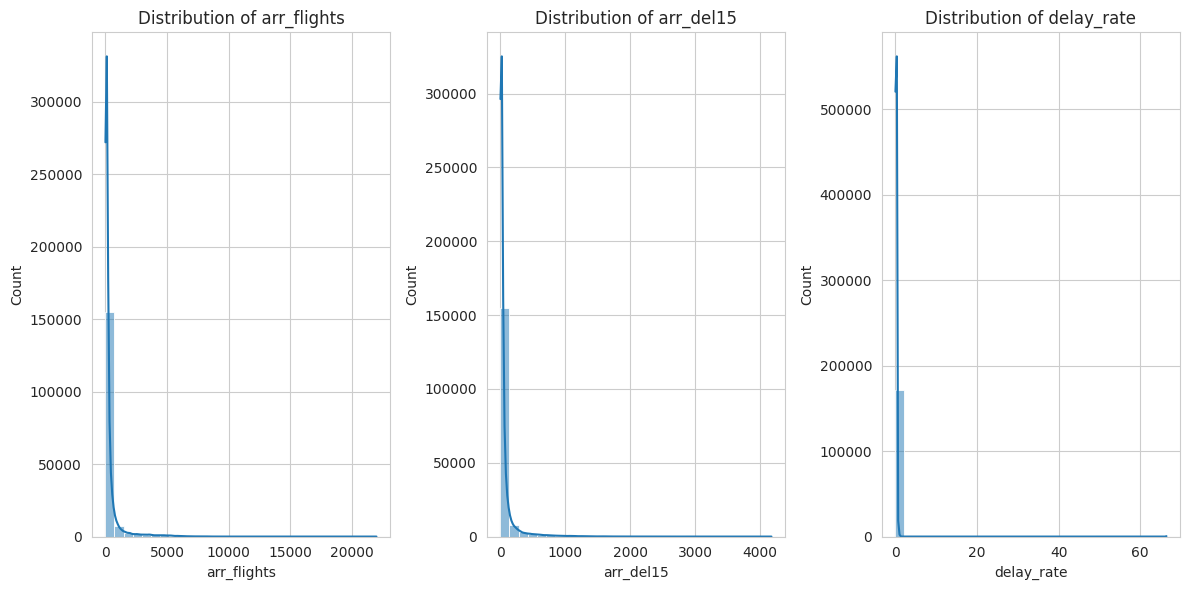

In [31]:
plt.figure(figsize=(12,6))
for i, col in enumerate(['arr_flights','arr_del15','delay_rate']):
    plt.subplot(1,3,i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

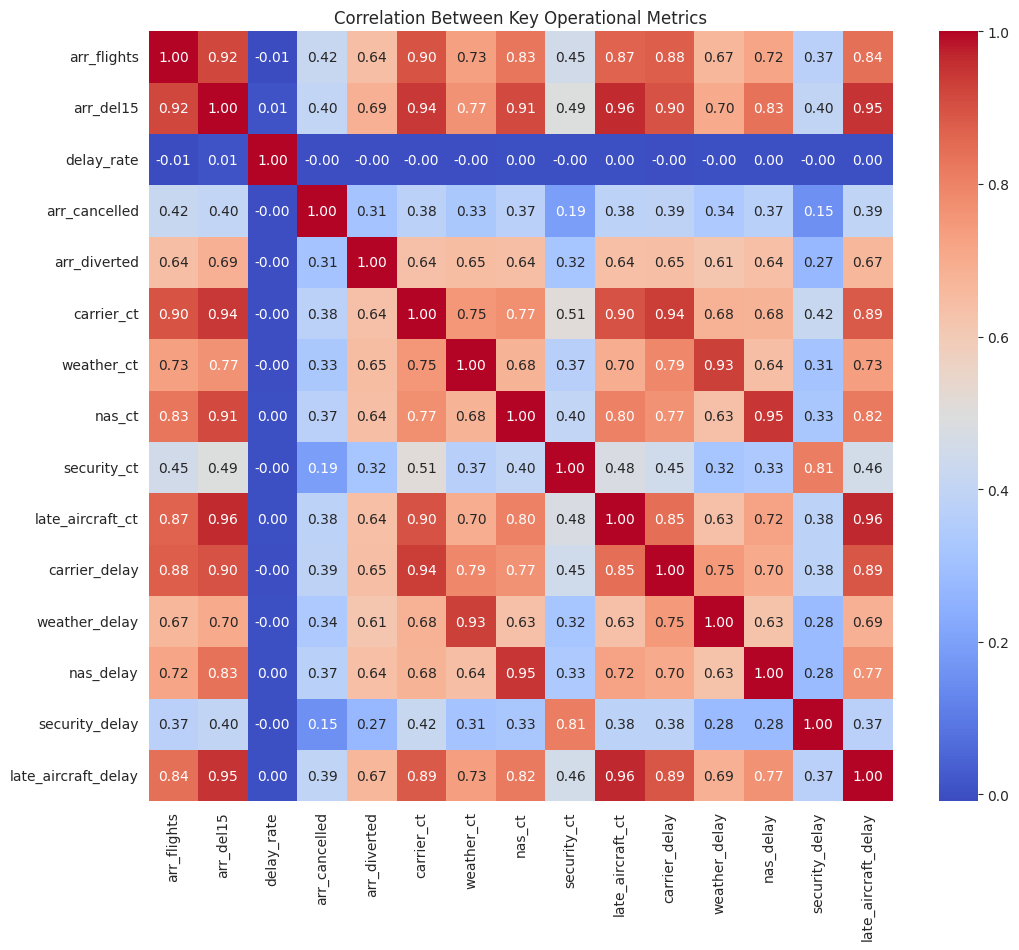

In [32]:
selected_cols = [ 'arr_flights', 'arr_del15', 'delay_rate', 'arr_cancelled',
                 'arr_diverted', 'carrier_ct',
                 'weather_ct', 'nas_ct', 'security_ct', 'late_aircraft_ct',
                 'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay',
                 'late_aircraft_delay' ]
corr = df[selected_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Key Operational Metrics")
plt.show()

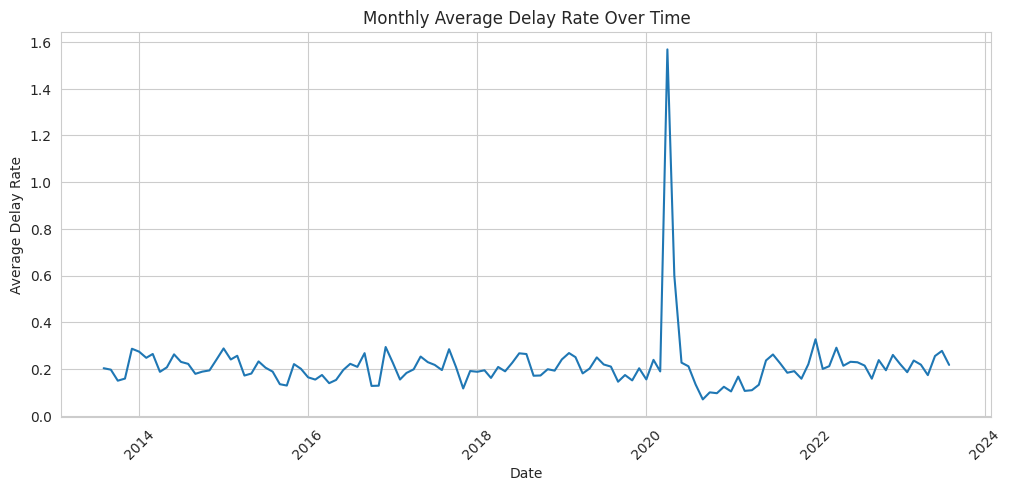

In [33]:
monthly = df.groupby('date')['delay_rate'].mean().reset_index()
#group by groups into index and
#reset index convert index back into colums
plt.figure(figsize=(12,5))
sns.lineplot(x='date', y='delay_rate', data=monthly)
plt.title("Monthly Average Delay Rate Over Time")
plt.xlabel("Date")
plt.ylabel("Average Delay Rate")
plt.xticks(rotation=45)
plt.show()


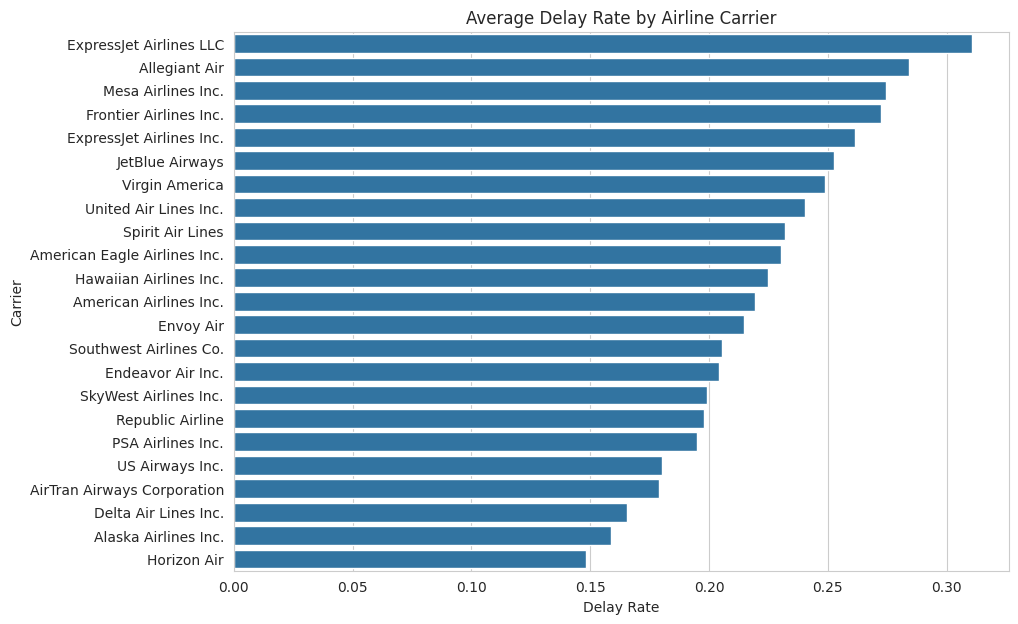

In [34]:
avg_carrier = df.groupby('carrier_name')['delay_rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,7))
sns.barplot(x=avg_carrier.values, y=avg_carrier.index)
plt.title("Average Delay Rate by Airline Carrier")
plt.xlabel("Delay Rate")
plt.ylabel("Carrier")
plt.show()

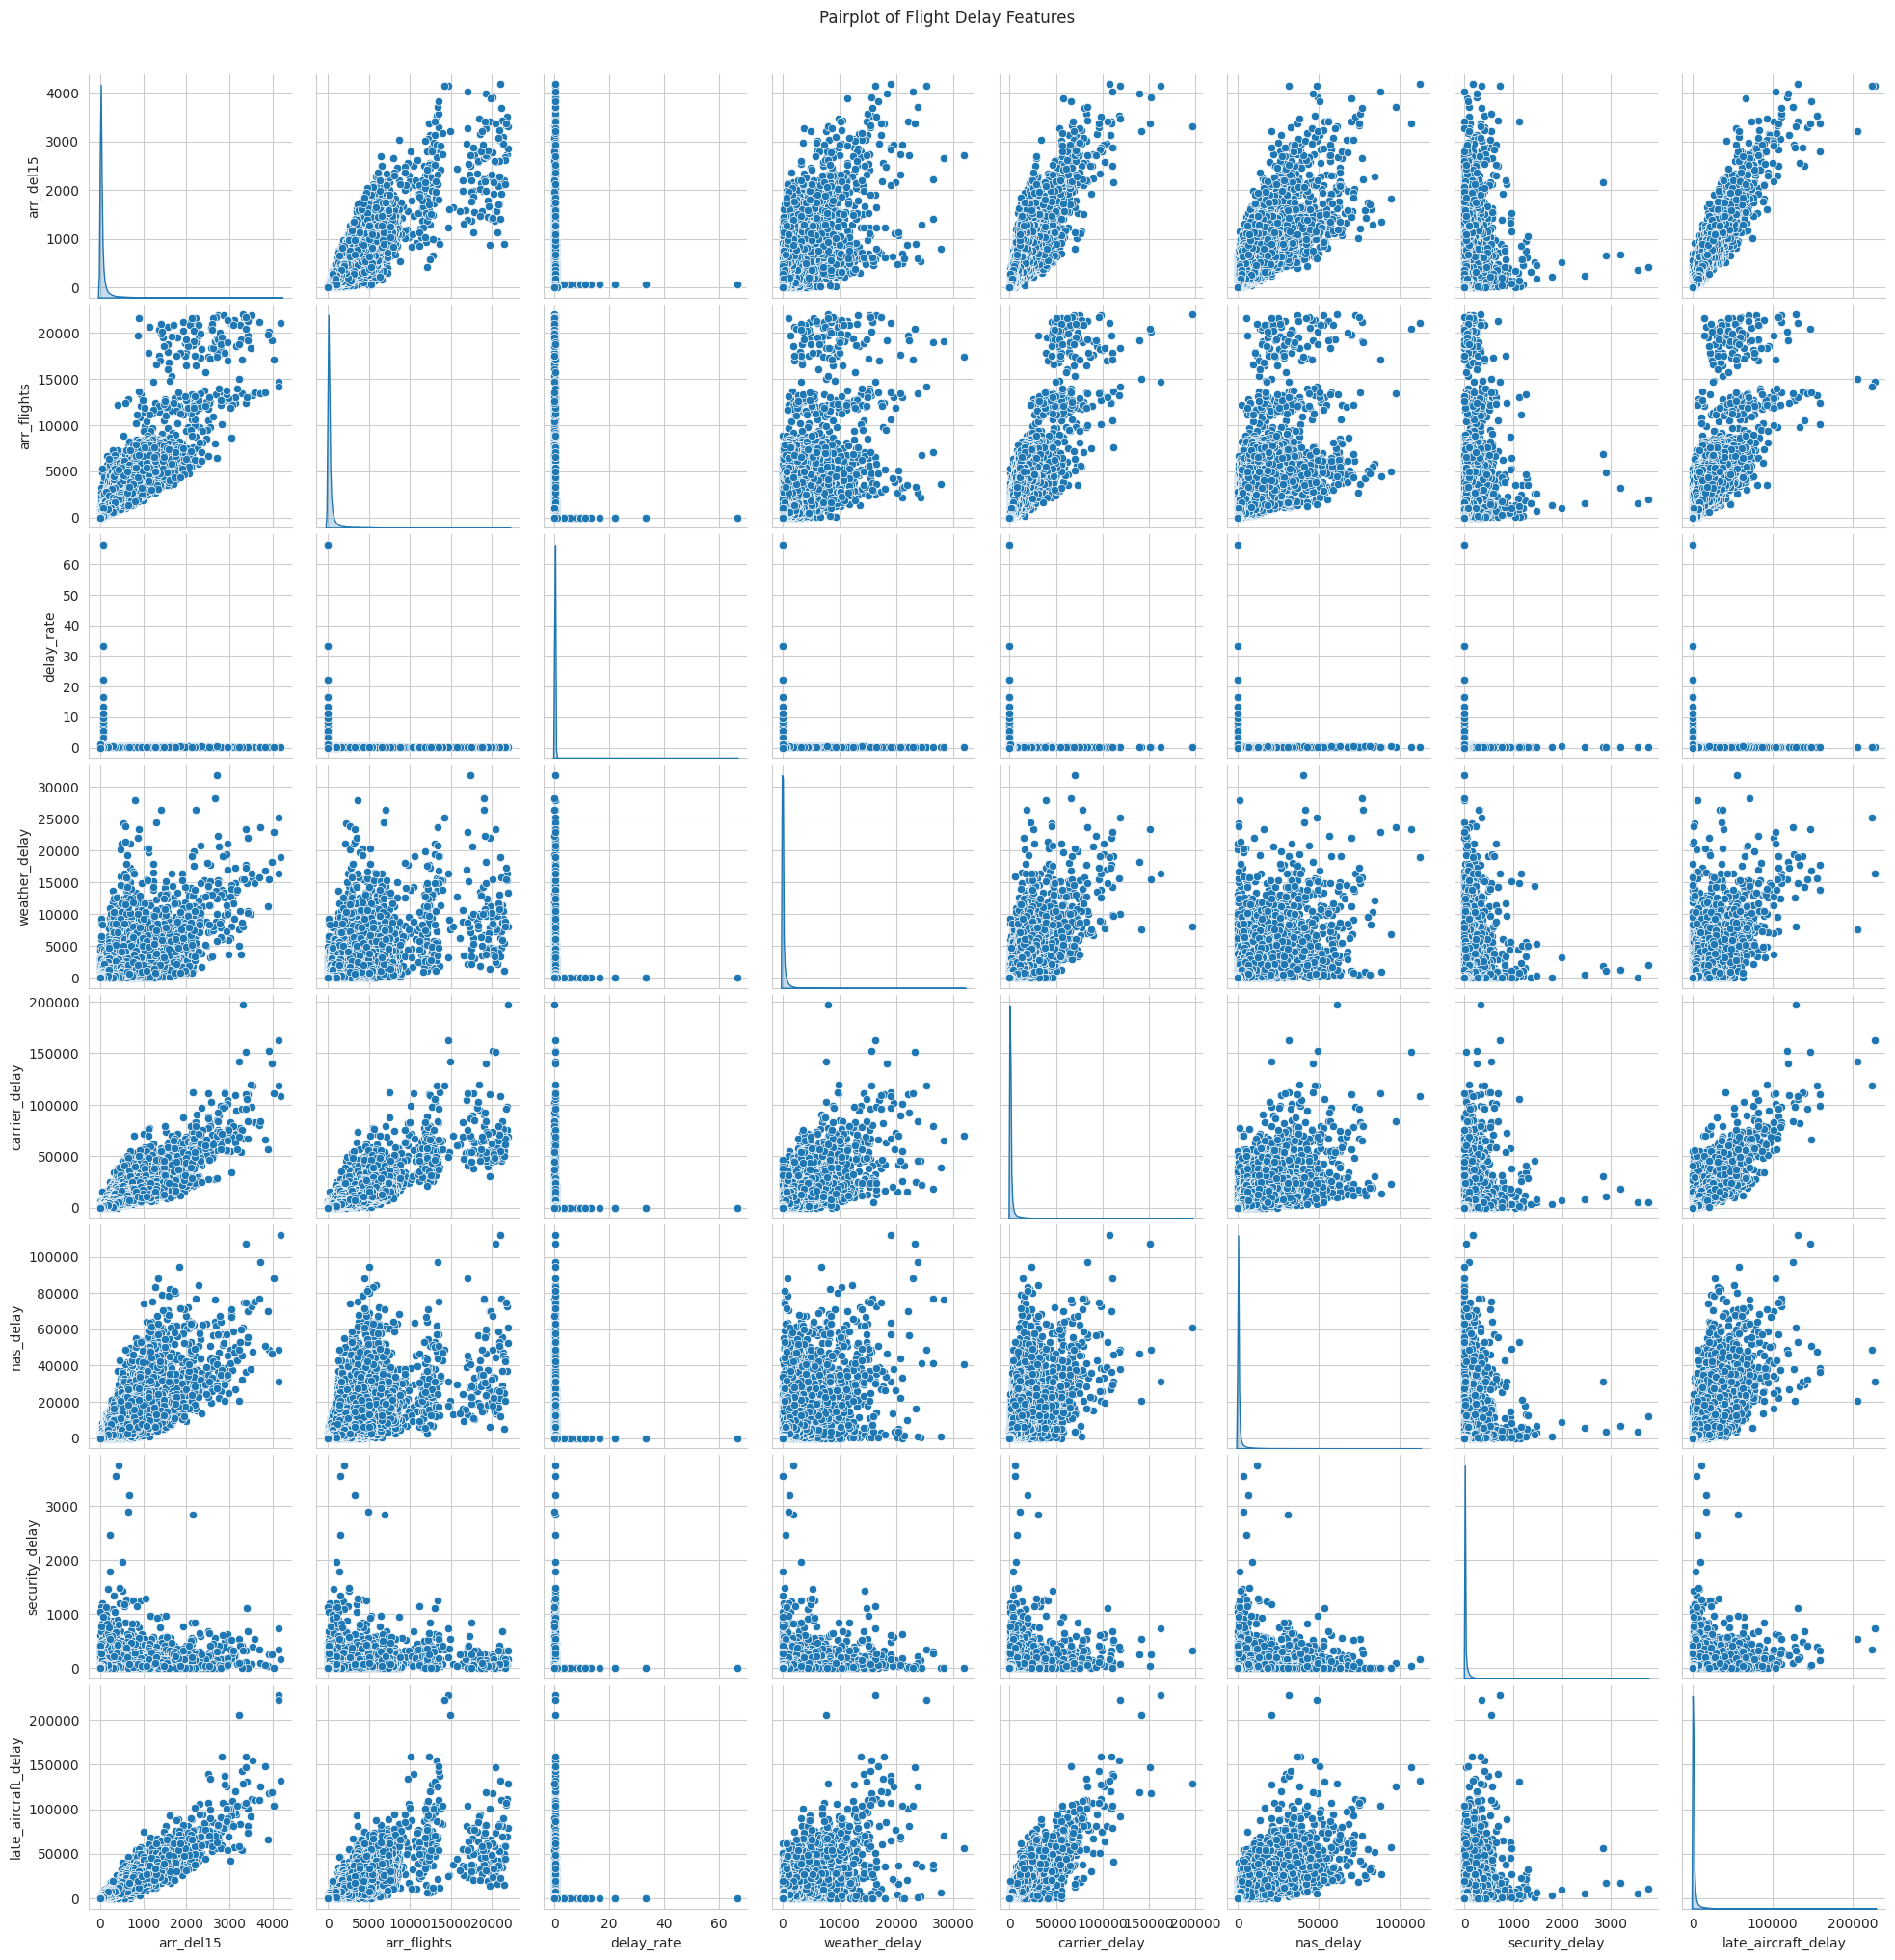

In [35]:
num_cols = [
    'arr_del15',
    'arr_flights',
    'delay_rate',
    'weather_delay',
    'carrier_delay',
    'nas_delay',
    'security_delay',
    'late_aircraft_delay'
]

sns.pairplot(df[num_cols], diag_kind='kde')
plt.suptitle("Pairplot of Flight Delay Features", y=1.02)
plt.show()